# Q2 — Which Satisfaction Dimension Drags the Composite Score Most

**Question:** Of the six satisfaction dimensions, which one most drags down the composite score?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


For each dimension: mean score, correlation with the composite, and the gap between the dimension's mean and the composite's mean. A low mean + high correlation means that dimension is dragging the composite down the most.

In [2]:
dims = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

composite_mean = df["satisfaction_composite"].mean()
rows = []
for dim in dims:
    rows.append({
        "dimension": dim.replace("satisfaction_", ""),
        "mean_score": df[dim].mean(),
        "corr_with_composite": df[dim].corr(df["satisfaction_composite"]),
        "gap_vs_composite_mean": df[dim].mean() - composite_mean,
    })
satisfaction_drag = pd.DataFrame(rows).set_index("dimension").sort_values("mean_score")
satisfaction_drag

,mean_score,corr_with_composite,gap_vs_composite_mean
dimension,,,
salary,4.27,0.77,-0.98
mobility,4.76,0.86,-0.49
management,5.33,0.88,0.08
learning,5.61,0.80,0.36
worklife,5.74,0.82,0.49
coworkers,5.86,0.85,0.61


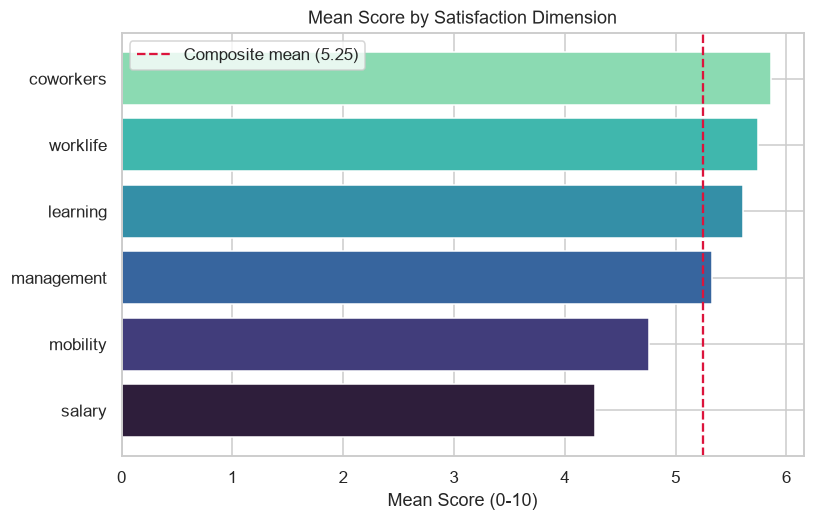

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
data = satisfaction_drag.reset_index()
colors = sns.color_palette("mako", len(data))
ax.barh(data["dimension"], data["mean_score"], color=colors)
ax.axvline(composite_mean, color="crimson", linestyle="--",
           label=f"Composite mean ({composite_mean:.2f})")
ax.set_title("Mean Score by Satisfaction Dimension")
ax.set_xlabel("Mean Score (0-10)")
ax.legend()
fig.savefig(OUT / "q2_satisfaction_dimension_means.png", bbox_inches="tight")
plt.show()

**Takeaway:** `salary` satisfaction is both the lowest-scoring dimension *and* strongly correlated with the composite (r ~ 0.77) — it's the biggest drag on overall satisfaction. `mobility` is a close second.

# Q2b — Satisfaction Extras: Median Scores & Pay-vs-Pay-Satisfaction Correlation

**Question:** What's the median (not just mean) score per dimension, and how strongly does actual salary correlate with salary satisfaction specifically?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

DIMS = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Mean + median score per dimension

In [3]:
rows = []
for dim in DIMS:
    rows.append({
        "dimension": dim.replace("satisfaction_", ""),
        "avg_score": df[dim].mean(),
        "median_score": df[dim].median(),
    })
dim_scores = pd.DataFrame(rows).set_index("dimension").sort_values("avg_score")
dim_scores

,avg_score,median_score
dimension,,
salary,4.27,4.00
mobility,4.76,5.00
management,5.33,5.00
learning,5.61,6.00
worklife,5.74,6.00
coworkers,5.86,6.00


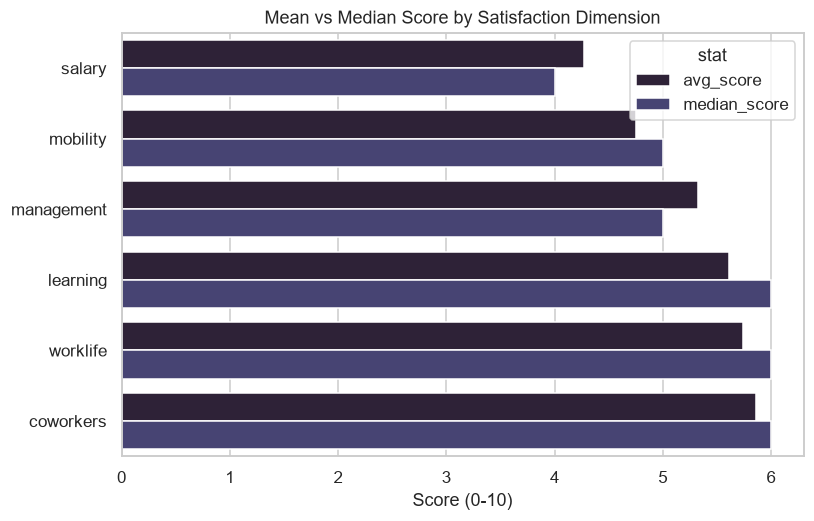

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
data = dim_scores.reset_index().melt(id_vars="dimension", var_name="stat", value_name="score")
sns.barplot(data=data, y="dimension", x="score", hue="stat", ax=ax)
ax.set_title("Mean vs Median Score by Satisfaction Dimension")
ax.set_xlabel("Score (0-10)")
ax.set_ylabel("")
fig.savefig(OUT / "q2b_mean_vs_median_by_dimension.png", bbox_inches="tight")
plt.show()

### Full correlation table (each dimension vs composite, plus pay vs pay-satisfaction)

In [8]:
corr_rows = []
for dim in DIMS:
    corr_rows.append({
        "dimension": dim.replace("satisfaction_", ""),
        "correlation": df[dim].corr(df["satisfaction_composite"]),
    })
corr_rows.append({
    "dimension": "pay_vs_paysat (salary_midpoint vs satisfaction_salary)",
    "correlation": df["salary_midpoint"].corr(df["satisfaction_salary"]),
})
corr_table = pd.DataFrame(corr_rows).set_index("dimension").sort_values("correlation", ascending=False)
corr_table

,correlation
dimension,
management,0.88
mobility,0.86
coworkers,0.85
worklife,0.82
learning,0.80
salary,0.77
pay_vs_paysat (salary_midpoint vs satisfaction_salary),0.49


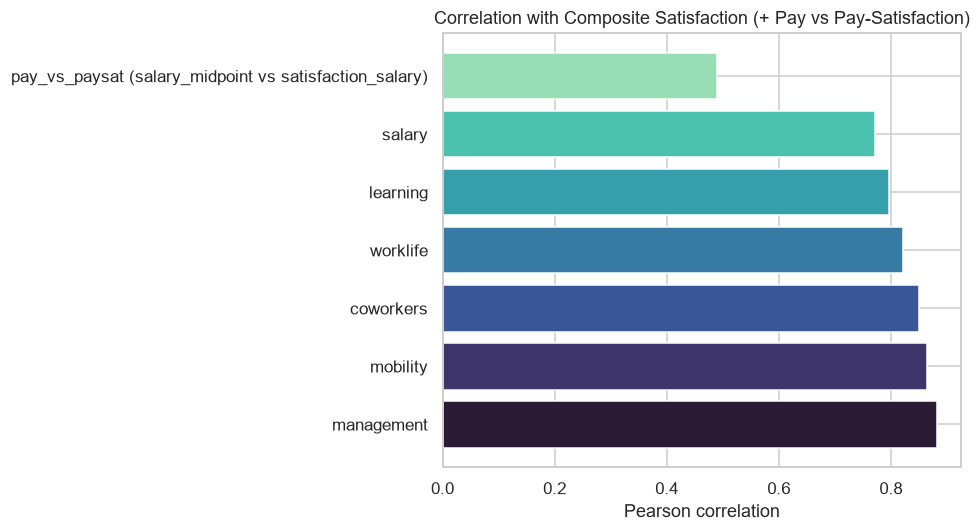

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
data = corr_table.reset_index()
colors = sns.color_palette("mako", len(data))
ax.barh(data["dimension"], data["correlation"], color=colors)
ax.set_title("Correlation with Composite Satisfaction (+ Pay vs Pay-Satisfaction)")
ax.set_xlabel("Pearson correlation")
fig.tight_layout()
fig.savefig(OUT / "q2b_correlation_table.png", bbox_inches="tight")
plt.show()

**Takeaway:** Actual salary and salary-satisfaction are only weakly-to-moderately correlated — how much someone earns doesn't fully predict how satisfied they feel about their pay. Perception matters as much as the number itself.